In [1]:
import sys
sys.path.append('../../')
sys.path.append('../../src')
from swimpde.domain import ResamplingDomain
from adaptive_swim.ansatz import BasicAnsatz
from swimpde.solver import TimeDependentSolver
from swimpde.equation import Burgers
import numpy as np
import scipy
import time
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'jet'
from utils import filter_results

Load data and reference solution

In [2]:
# Load and visualize data
data = scipy.io.loadmat('data/burgers_shock.mat')
t_eval = data['t'].flatten()[:,None]
x_eval = data['x'].flatten()[:,None]
u_exact = np.real(data['usol'])
X, T = np.meshgrid(x_eval,t_eval)
X_ = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))

# Set ground truth
u_true = u_exact.flatten()[:,None]              

Problem setup

In [3]:
# initial condition
def u0(x):
    return -1 * np.sin(np.pi * x)

# forcing
def forcing(x, t):
    return np.zeros(x.shape[0])

# boundary condition
boundary_condition = "zero dirichlet" # 

# Domain information and spacial points for the first time-block
n_points_1d = 4000 # No. of points in space
x_lim = [-1, 1] # Domain range

# Interior points
rng = np.random.default_rng(seed=123)
x_space = rng.uniform(x_lim[0], x_lim[1], n_points_1d).reshape((-1, 1)) 
x_space_inner = x_space[1:-1]
interior_points = x_space_inner

# Boundary points (excluding corners)
left = x_lim[0]
right = x_lim[1]
boundary_points = np.row_stack([left, right])

/var/folders/q0/trwlbpyx2sn3p0dddjc7fvkw0000gn/T/ipykernel_90785/3795381570.py:25: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  boundary_points = np.row_stack([left, right])


In [2]:
# Parameters of the solver 
activations = ["tanh", "a_tanh", "rational"]
n_bases = [50, 100, 200, 400, 600]
s_list = [0.5, 1.0]
k_list = [5, 10, 20, 40]
seeds = [1, 2, 3]

In [5]:
# Hyper-parameters

n_sample_small = 1000
n_sample_large = 4000
time_blocks = 9

# Define prob. distribution for (re)-sampling collocation points
def collocation_points_probabilities(df_dx):
    gradients = np.abs(df_dx)
    gradients = gradients + 0.03 * np.max(gradients)
    return gradients/np.sum(gradients)

# Points where gradient of the solution at the end of a time-block is computed
sample_points_list = [
    np.linspace(x_lim[0] + 1e-6, x_lim[1] - 1e-6, n_sample_small).reshape((-1, 1)),
    np.linspace(x_lim[0] + 1e-6, x_lim[1] - 1e-6, n_sample_large).reshape((-1, 1))] # This does not include boundary points

# Domain
def get_domain(seed, sample_points):
    return ResamplingDomain(
        interior_points=interior_points,
        boundary_points=boundary_points,
        sample_points = sample_points,
        resampling_pdf=collocation_points_probabilities,
        random_seed=seed,
    )

In [6]:
# config_speed: Frozen-PINN-swim with high speed for an accuracy comparable to vanilla PINN
config_speed = {
    "sample_points": sample_points_list[0],
    "reg_const": 1e-8,                # Regularization constant
    "svd_cutoff": 1e-8,               # SVD threshold
    "tol": 1e-6,                      # Tolerance
}

# config_accuracy: Frozen-PINN-swim with high accuracy
config_accuracy = {
    "sample_points": sample_points_list[1],
    "reg_const": 1e-13,              # Regularization constant
    "svd_cutoff": 5e-11,             # SVD threshold
    "tol": 1e-6,                     # Tolerance
}

Solve the equation

In [ ]:
experiments = []
equation = Burgers(u0=u0, nu=0.01/np.pi)

for n_basis in n_bases:
    if n_basis < 600:
        config = config_speed
    else:
        config = config_accuracy
    for activation in activations:
        if activation == "tanh":
            s_sublist = [0.0]  # dummy variable
            k_sublist = [0]  # dummy variable
        elif activation == "a_tanh":
            s_sublist = [0.0]  # dummy variable
            k_sublist = k_list
        else:
            s_sublist = s_list
            k_sublist = k_list
        for s in s_sublist:
            for k in k_sublist:
                for seed in seeds:
                    # Define the ansatz.
                    ansatz = BasicAnsatz(
                        n_basis=n_basis,
                        activation=activation,
                        random_seed=seed,
                        initial_condition=u0,
                        svd_cutoff=config["svd_cutoff"],
                        #repetition_scaler=1,
                        k=k,
                        s=s,
                    )

                    domain = get_domain(seed, config["sample_points"])
                    
                    # Define the solver.
                    solver = TimeDependentSolver(
                        domain=domain,
                        ansatz=ansatz,
                        forcing=forcing,
                        forced_boundary_condition=boundary_condition,
                        equation=equation,
                        regularization_scale=config["reg_const"],
                        rtol=config["tol"],
                        atol=config["tol"],
                        ode_solver='LSODA',
                        resample_domain=True,
                    )
                    
                    # Fit the solver.
                    start_fit = time.time()
                    solver.fit(t_span=[0, np.max(t_eval)], n_time_blocks=time_blocks)
                    end_fit = time.time()
                    train_time = end_fit - start_fit
            
                    u_pred = solver.evaluate(x_eval, t_eval)
                    rmse = np.linalg.norm(u_pred - u_exact) / u_pred.shape[0]
                    rel_l2 = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
                
                    experiments.append({
                        "activation": activation,
                        "n_inner": n_basis,
                        "(s_1, s_2)": (-s, s),
                        "k": k,
                        "rmse": rmse,
                        "rel_l2": rel_l2,
                        "time": train_time,
                        "seed": seed,
                    })
                
                    print(experiments[-1])

In [8]:
# Save results
import pandas as pd
df = pd.DataFrame(experiments)
df.to_csv("results/burgers_results.csv", index=False)

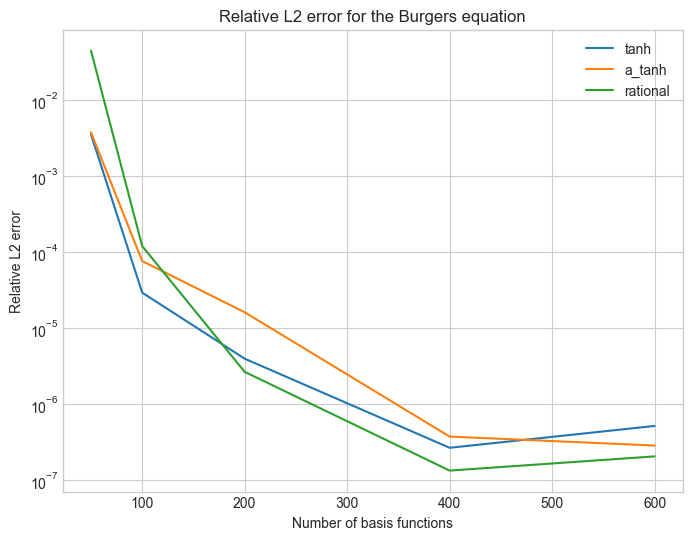

In [ ]:
import pandas as pd
df = pd.read_csv("results/burgers_results.csv")
df = df.groupby(["activation", "n_inner", "(s_1, s_2)", "k"]).agg(rmse=("rmse", "mean"),
                                                                  rmse_std=("rmse", "std"),
                                                                  rel_l2=("rel_l2", "mean"),
                                                                  rel_l2_std=("rel_l2", "std"),
                                                                  time=("time", "mean"),
                                                                  time_std=("time", "std")).reset_index()
df.to_csv("results/burgers_accuracy.csv")

n_bases = [50, 100, 200, 400, 600]
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

n_inner_np = np.asarray(n_bases)
for activation in activations:
    rmse, rel_l2 = filter_results(df, activation, n_bases)
    plt.plot(n_inner_np, rel_l2, label=activation)

plt.title("Relative L2 error for the Burgers equation")
plt.xlabel("Number of basis functions")
plt.ylabel("Relative L2 error")
plt.yscale("log")
plt.legend()
plt.show()

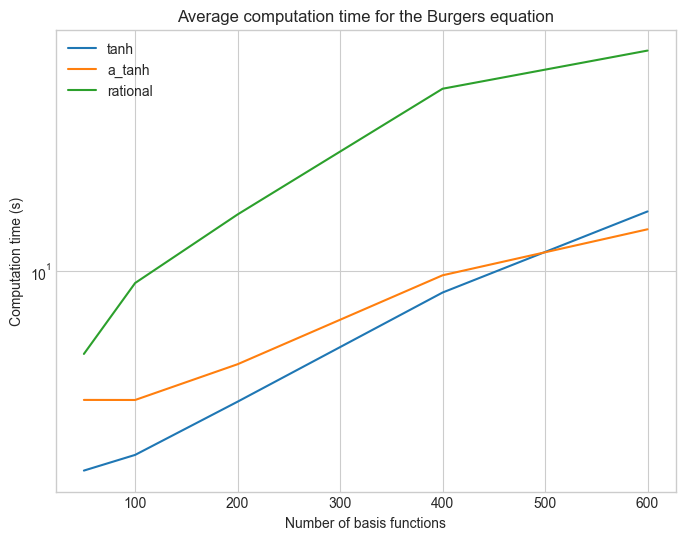

In [ ]:
import pandas as pd
df = pd.read_csv("results/burgers_results.csv")
df = df.groupby(["activation", "n_inner"]).agg(time=("time", "mean"),
                                               time_std=("time", "std")).reset_index()
df.to_csv("results/burgers_time.csv")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 6))

n_inner_np = np.asarray(n_bases)

for activation in activations:
    time_list = []
    filtered = df[df["activation"] == activation]
    for n in n_bases:
        subset = filtered[filtered["n_inner"] == n]
        time_ = subset["time"]
        time_list.append(time_)
    y_time = np.array(time_list)
    
    plt.plot(n_inner_np, y_time, label=activation)

plt.title("Average computation time for the Burgers equation")
plt.xlabel("Number of basis functions")
plt.ylabel("Computation time (s)")
plt.yscale("log")
plt.legend()
plt.show()